In [14]:
"""
==========================================================
StreamFlix Content Analytics Project
Phase 1 : Data Loading & Quality Check
Author : Sujal
==========================================================
"""

import os
import logging
from datetime import datetime

import numpy as np
import pandas as pd

import time
start_time = time.time()

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

# Create folders automatically
folders = [
    "logs",
    "reports",
    "data/cleaned"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# ----------------------------------------------------------
# LOGGING CONFIGURATION
# ----------------------------------------------------------

log_file = f"logs/phase1_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logging.basicConfig(

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    handlers=[

        logging.FileHandler(log_file),

        logging.StreamHandler()

    ]

)

logger = logging.getLogger(__name__)

logger.info("=" * 80)
logger.info("STREAMFLIX DATA CLEANING STARTED")
logger.info("=" * 80)

2026-07-21 16:44:28,237 | INFO | ================================================================================
2026-07-21 16:44:28,240 | INFO | STREAMFLIX DATA CLEANING STARTED
2026-07-21 16:44:28,242 | INFO | ================================================================================


In [15]:
RAW_PATH = "data/raw"

FILES = {

    "subscribers":
        f"{RAW_PATH}/subscribers.csv",

    "titles":
        f"{RAW_PATH}/titles.csv",

    "watch_history":
        f"{RAW_PATH}/watch_history.csv",

    "ratings":
        f"{RAW_PATH}/ratings.csv",

    "reviews":
        f"{RAW_PATH}/reviews.csv",

    "watchlist":
        f"{RAW_PATH}/watchlist.csv"

}

In [16]:
def load_csv(path):

    """
    Loads a csv safely.
    """

    try:

        logger.info(f"Loading {path}")

        df = pd.read_csv(path)

        logger.info(f"Loaded Successfully")

        logger.info(f"Rows : {df.shape[0]}")

        logger.info(f"Columns : {df.shape[1]}")

        return df

    except Exception as e:

        logger.error(e)

        raise

In [17]:
subscribers = load_csv(FILES["subscribers"])

titles = load_csv(FILES["titles"])

watch_history = load_csv(FILES["watch_history"])

ratings = load_csv(FILES["ratings"])

reviews = load_csv(FILES["reviews"])

watchlist = load_csv(FILES["watchlist"])

logger.info("All datasets loaded successfully.")

2026-07-21 16:44:28,309 | INFO | Loading data/raw/subscribers.csv
2026-07-21 16:44:28,375 | INFO | Loaded Successfully
2026-07-21 16:44:28,379 | INFO | Rows : 15000
2026-07-21 16:44:28,380 | INFO | Columns : 14
2026-07-21 16:44:28,382 | INFO | Loading data/raw/titles.csv
2026-07-21 16:44:28,458 | INFO | Loaded Successfully
2026-07-21 16:44:28,459 | INFO | Rows : 9000
2026-07-21 16:44:28,461 | INFO | Columns : 21
2026-07-21 16:44:28,462 | INFO | Loading data/raw/watch_history.csv
2026-07-21 16:44:29,751 | INFO | Loaded Successfully
2026-07-21 16:44:29,752 | INFO | Rows : 650000
2026-07-21 16:44:29,753 | INFO | Columns : 10
2026-07-21 16:44:29,754 | INFO | Loading data/raw/ratings.csv
2026-07-21 16:44:29,939 | INFO | Loaded Successfully
2026-07-21 16:44:29,941 | INFO | Rows : 130000
2026-07-21 16:44:29,943 | INFO | Columns : 5
2026-07-21 16:44:29,946 | INFO | Loading data/raw/reviews.csv
2026-07-21 16:44:30,257 | INFO | Loaded Successfully
2026-07-21 16:44:30,260 | INFO | Rows : 110000
2

In [18]:
datasets = {

    "Subscribers": subscribers,

    "Titles": titles,

    "Watch History": watch_history,

    "Ratings": ratings,

    "Reviews": reviews,

    "Watchlist": watchlist

}

In [19]:
def dataset_overview(name, df):

    logger.info("=" * 60)

    logger.info(name.upper())

    logger.info("=" * 60)

    print("\n")

    print(f"Dataset : {name}")

    print("-" * 60)

    print("Shape")

    print(df.shape)

    print()

    print("Columns")

    print(df.columns.tolist())

    print()

    print("Data Types")

    print(df.dtypes)

    print()

    print("First Five Rows")

    print(df.head())

    print()

    print("Last Five Rows")

    print(df.tail())

    print()

    print("Statistical Summary")

    print(df.describe(include="all").T)

    print("\n")

In [20]:
for name, dataframe in datasets.items():

    dataset_overview(name, dataframe)

2026-07-21 16:44:30,469 | INFO | ============================================================
2026-07-21 16:44:30,471 | INFO | SUBSCRIBERS
2026-07-21 16:44:30,474 | INFO | ============================================================
2026-07-21 16:44:30,562 | INFO | ============================================================
2026-07-21 16:44:30,563 | INFO | TITLES
2026-07-21 16:44:30,565 | INFO | ============================================================
2026-07-21 16:44:30,666 | INFO | ============================================================
2026-07-21 16:44:30,667 | INFO | WATCH HISTORY
2026-07-21 16:44:30,669 | INFO | ============================================================




Dataset : Subscribers
------------------------------------------------------------
Shape
(15000, 14)

Columns
['subscriber_id', 'signup_date', 'country', 'region', 'age', 'gender', 'plan_type', 'monthly_price_usd', 'household_size', 'primary_device', 'payment_method', 'tenure_months', 'is_active', 'churn_date']

Data Types
subscriber_id         object
signup_date           object
country               object
region                object
age                    int64
gender                object
plan_type             object
monthly_price_usd    float64
household_size         int64
primary_device        object
payment_method        object
tenure_months          int64
is_active               bool
churn_date            object
dtype: object

First Five Rows
  subscriber_id signup_date         country         region  age  gender       plan_type  monthly_price_usd  household_size   primary_device  \
0     SUB100000  2023-01-09          France         Europe   22  Female  Basic with Ads      

2026-07-21 16:44:31,452 | INFO | ============================================================
2026-07-21 16:44:31,455 | INFO | RATINGS
2026-07-21 16:44:31,457 | INFO | ============================================================
2026-07-21 16:44:31,560 | INFO | ============================================================
2026-07-21 16:44:31,562 | INFO | REVIEWS
2026-07-21 16:44:31,564 | INFO | ============================================================


                         count unique            top    freq        mean            std   min        25%       50%        75%       max
watch_id              650000.0    NaN            NaN     NaN    325000.5  187638.981824   1.0  162500.75  325000.5  487500.25  650000.0
subscriber_id           650000  14998      SUB107911    5989         NaN            NaN   NaN        NaN       NaN        NaN       NaN
title_id                650000   9000      TTL205962    4436         NaN            NaN   NaN        NaN       NaN        NaN       NaN
watch_date              650000   2616     2026-05-31   18227         NaN            NaN   NaN        NaN       NaN        NaN       NaN
device                  650000      6       Smart TV  221446         NaN            NaN   NaN        NaN       NaN        NaN       NaN
region                  650000      9  North America  197412         NaN            NaN   NaN        NaN       NaN        NaN       NaN
content_duration_min  650000.0    NaN           

2026-07-21 16:44:31,699 | INFO | ============================================================
2026-07-21 16:44:31,701 | INFO | WATCHLIST
2026-07-21 16:44:31,702 | INFO | ============================================================


                  count unique                                               top   freq      mean           std  min       25%      50%       75%  \
review_id      110000.0    NaN                                               NaN    NaN   55000.5  31754.409143  1.0  27500.75  55000.5  82500.25   
subscriber_id    110000  14991                                         SUB106939     20       NaN           NaN  NaN       NaN      NaN       NaN   
title_id         110000   8999                                         TTL207141    743       NaN           NaN  NaN       NaN      NaN       NaN   
review_text      110000     20  Couldn't stop watching — binged it in a weekend.   9518       NaN           NaN  NaN       NaN      NaN       NaN   
sentiment        110000      3                                          Positive  75007       NaN           NaN  NaN       NaN      NaN       NaN   
helpful_votes  110000.0    NaN                                               NaN    NaN  7.409618      3.5

In [21]:
def memory_usage(df):

    memory = df.memory_usage(deep=True).sum() / 1024**2

    logger.info(f"Memory Usage : {memory:.2f} MB")

    return memory

In [22]:
def dataframe_info(df):

    info = pd.DataFrame({

        "Column":

            df.columns,

        "Data Type":

            df.dtypes.values,

        "Missing Values":

            df.isnull().sum().values,

        "Unique":

            df.nunique().values

    })

    return info

In [23]:
for name, dataframe in datasets.items():
    print()
    print("="*80)
    print(name)
    print("="*80)
    print(dataframe_info(dataframe))


Subscribers
               Column Data Type  Missing Values  Unique
0       subscriber_id    object               0   15000
1         signup_date    object               0    3435
2             country    object               0      20
3              region    object               0       9
4                 age     int64               0      70
5              gender    object               0       4
6           plan_type    object               0       3
7   monthly_price_usd   float64               0       3
8      household_size     int64               0       4
9      primary_device    object               0       6
10     payment_method    object               0       6
11      tenure_months     int64               0     126
12          is_active      bool               0       2
13         churn_date    object           11199    1667

Titles
                  Column Data Type  Missing Values  Unique
0               title_id    object               0    9000
1             title_n

In [24]:
# ----------------------------------------------------------
# MISSING VALUE SUMMARY
# ----------------------------------------------------------

def missing_value_summary(df, name):

    logger.info(f"Checking Missing Values : {name}")

    missing = pd.DataFrame({

        "Column": df.columns,

        "Missing Values": df.isna().sum(),

        "Percentage": round((df.isna().sum()/len(df))*100,2),

        "Data Type": df.dtypes

    })

    missing = missing.sort_values(
        by="Missing Values",
        ascending=False
    )

    return missing

In [25]:
for name, dataframe in datasets.items():

    print("\n")
    print("="*90)
    print(name.upper())
    print("="*90)

    print(missing_value_summary(dataframe,name))

2026-07-21 16:44:32,880 | INFO | Checking Missing Values : Subscribers
2026-07-21 16:44:32,914 | INFO | Checking Missing Values : Titles
2026-07-21 16:44:32,937 | INFO | Checking Missing Values : Watch History




SUBSCRIBERS
                              Column  Missing Values  Percentage Data Type
churn_date                churn_date           11199       74.66    object
subscriber_id          subscriber_id               0        0.00    object
country                      country               0        0.00    object
region                        region               0        0.00    object
age                              age               0        0.00     int64
signup_date              signup_date               0        0.00    object
gender                        gender               0        0.00    object
plan_type                  plan_type               0        0.00    object
household_size        household_size               0        0.00     int64
monthly_price_usd  monthly_price_usd               0        0.00   float64
primary_device        primary_device               0        0.00    object
payment_method        payment_method               0        0.00    object
tenure_mont

2026-07-21 16:44:33,338 | INFO | Checking Missing Values : Ratings
2026-07-21 16:44:33,408 | INFO | Checking Missing Values : Reviews
2026-07-21 16:44:33,491 | INFO | Checking Missing Values : Watchlist


                                    Column  Missing Values  Percentage Data Type
watch_id                          watch_id               0         0.0     int64
subscriber_id                subscriber_id               0         0.0    object
title_id                          title_id               0         0.0    object
watch_date                      watch_date               0         0.0    object
device                              device               0         0.0    object
region                              region               0         0.0    object
content_duration_min  content_duration_min               0         0.0     int64
watch_duration_min      watch_duration_min               0         0.0   float64
completion_pct              completion_pct               0         0.0   float64
completed                        completed               0         0.0      bool


RATINGS
                      Column  Missing Values  Percentage Data Type
rating_id          rating_id    

In [26]:
import matplotlib.pyplot as plt

def plot_missing_values(df,name):

    missing=df.isnull().sum()

    missing=missing[missing>0]

    if len(missing)==0:

        logger.info(f"{name} : No Missing Values")

        return

    plt.figure(figsize=(12,5))

    missing.sort_values().plot(
        kind="barh"
    )

    plt.title(f"Missing Values - {name}")

    plt.xlabel("Count")

    plt.tight_layout()

    plt.show()

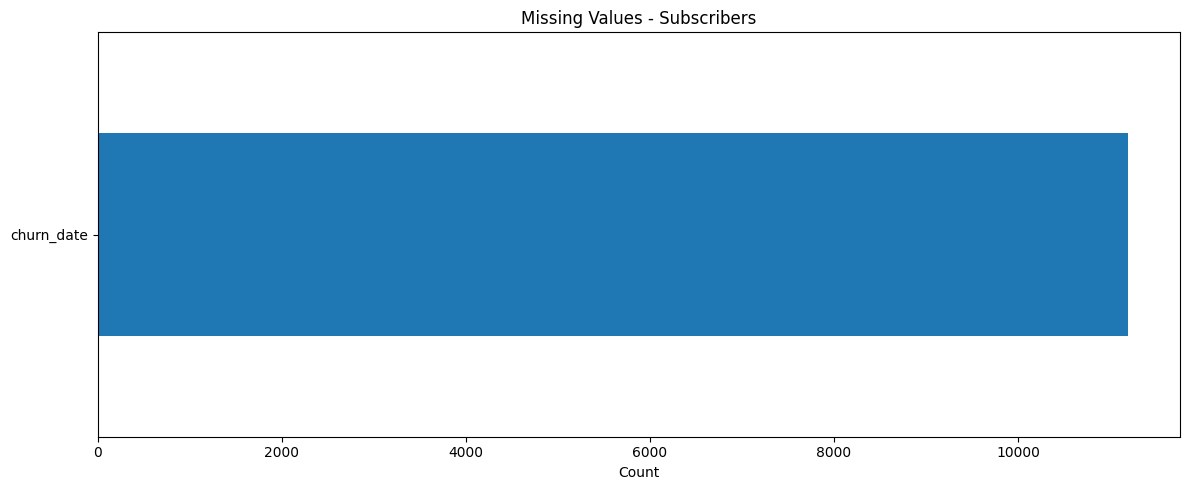

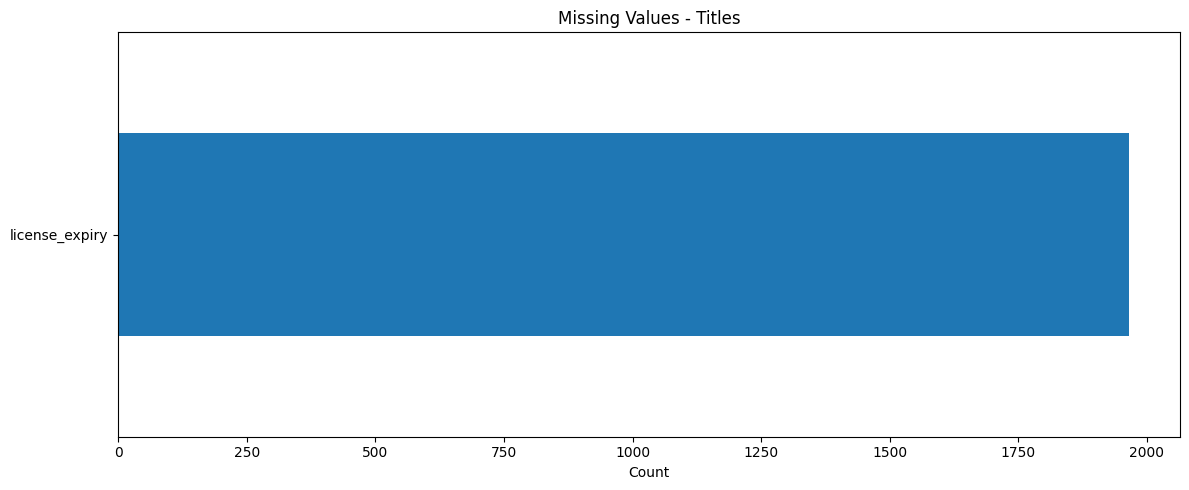

2026-07-21 16:44:39,500 | INFO | Watch History : No Missing Values
2026-07-21 16:44:39,529 | INFO | Ratings : No Missing Values
2026-07-21 16:44:39,565 | INFO | Reviews : No Missing Values
2026-07-21 16:44:39,581 | INFO | Watchlist : No Missing Values


In [27]:
for name,dataframe in datasets.items():

    plot_missing_values(dataframe,name)

In [28]:
# ----------------------------------------------------------
# DUPLICATE CHECK
# ----------------------------------------------------------

def duplicate_summary(df,name):

    duplicates=df.duplicated().sum()

    logger.info(
        f"{name} Duplicate Rows : {duplicates}"
    )

    print()

    print(name)

    print("Duplicate Rows :",duplicates)

In [29]:
for name,dataframe in datasets.items():

    duplicate_summary(dataframe,name)

2026-07-21 16:44:39,693 | INFO | Subscribers Duplicate Rows : 0
2026-07-21 16:44:39,717 | INFO | Titles Duplicate Rows : 0



Subscribers
Duplicate Rows : 0

Titles
Duplicate Rows : 0


2026-07-21 16:44:40,413 | INFO | Watch History Duplicate Rows : 0
2026-07-21 16:44:40,487 | INFO | Ratings Duplicate Rows : 0
2026-07-21 16:44:40,611 | INFO | Reviews Duplicate Rows : 0



Watch History
Duplicate Rows : 0

Ratings
Duplicate Rows : 0


2026-07-21 16:44:40,657 | INFO | Watchlist Duplicate Rows : 0



Reviews
Duplicate Rows : 0

Watchlist
Duplicate Rows : 0


In [30]:
def remove_duplicates(df,name):

    before=len(df)

    df=df.drop_duplicates()

    after=len(df)

    removed=before-after

    logger.info(

        f"{name} Removed {removed} duplicate rows."

    )

    return df

In [31]:
subscribers=remove_duplicates(subscribers,"Subscribers")

titles=remove_duplicates(titles,"Titles")

watch_history=remove_duplicates(
    watch_history,
    "Watch History"
)

ratings=remove_duplicates(
    ratings,
    "Ratings"
)

reviews=remove_duplicates(
    reviews,
    "Reviews"
)

watchlist=remove_duplicates(
    watchlist,
    "Watchlist"
)

2026-07-21 16:44:40,747 | INFO | Subscribers Removed 0 duplicate rows.
2026-07-21 16:44:40,789 | INFO | Titles Removed 0 duplicate rows.
2026-07-21 16:44:41,423 | INFO | Watch History Removed 0 duplicate rows.
2026-07-21 16:44:41,504 | INFO | Ratings Removed 0 duplicate rows.
2026-07-21 16:44:41,602 | INFO | Reviews Removed 0 duplicate rows.
2026-07-21 16:44:41,646 | INFO | Watchlist Removed 0 duplicate rows.


In [32]:
# ----------------------------------------------------------
# PRIMARY KEY CHECK
# ----------------------------------------------------------

primary_keys={

    "Subscribers":"subscriber_id",

    "Titles":"title_id",

    "Watch History":"watch_id",

    "Ratings":"rating_id",

    "Reviews":"review_id",

    "Watchlist":"watchlist_id"

}

In [33]:
def check_primary_key(df,key,name):

    duplicates=df[key].duplicated().sum()

    nulls=df[key].isnull().sum()

    logger.info(f"{name}")

    logger.info(f"Duplicate PK : {duplicates}")

    logger.info(f"Null PK : {nulls}")

    print()

    print(name)

    print("Duplicate PK :",duplicates)

    print("Null PK :",nulls)

In [34]:
tables={

    "Subscribers":subscribers,

    "Titles":titles,

    "Watch History":watch_history,

    "Ratings":ratings,

    "Reviews":reviews,

    "Watchlist":watchlist

}

for table in tables:

    check_primary_key(

        tables[table],

        primary_keys[table],

        table

    )

2026-07-21 16:44:41,746 | INFO | Subscribers
2026-07-21 16:44:41,749 | INFO | Duplicate PK : 0
2026-07-21 16:44:41,751 | INFO | Null PK : 0
2026-07-21 16:44:41,756 | INFO | Titles
2026-07-21 16:44:41,758 | INFO | Duplicate PK : 0
2026-07-21 16:44:41,761 | INFO | Null PK : 0
2026-07-21 16:44:41,801 | INFO | Watch History
2026-07-21 16:44:41,804 | INFO | Duplicate PK : 0
2026-07-21 16:44:41,809 | INFO | Null PK : 0
2026-07-21 16:44:41,833 | INFO | Ratings
2026-07-21 16:44:41,837 | INFO | Duplicate PK : 0
2026-07-21 16:44:41,840 | INFO | Null PK : 0
2026-07-21 16:44:41,849 | INFO | Reviews
2026-07-21 16:44:41,856 | INFO | Duplicate PK : 0
2026-07-21 16:44:41,859 | INFO | Null PK : 0
2026-07-21 16:44:41,864 | INFO | Watchlist
2026-07-21 16:44:41,866 | INFO | Duplicate PK : 0
2026-07-21 16:44:41,867 | INFO | Null PK : 0



Subscribers
Duplicate PK : 0
Null PK : 0

Titles
Duplicate PK : 0
Null PK : 0

Watch History
Duplicate PK : 0
Null PK : 0

Ratings
Duplicate PK : 0
Null PK : 0

Reviews
Duplicate PK : 0
Null PK : 0

Watchlist
Duplicate PK : 0
Null PK : 0


In [35]:
# ----------------------------------------------------------
# DATA TYPE VALIDATION
# ----------------------------------------------------------

date_columns=[

    "signup_date",

    "churn_date",

    "date_added",

    "license_expiry",

    "watch_date",

    "rating_date",

    "review_date",

    "added_date"

]

In [36]:
for dataframe in datasets.values():

    for column in dataframe.columns:

        if column in date_columns:

            dataframe[column]=pd.to_datetime(

                dataframe[column],

                errors="coerce"

            )

In [37]:
numeric_columns=[

    "monthly_price_usd",

    "household_size",

    "tenure_months",

    "release_year",

    "content_duration_min",

    "quality_score",

    "popularity_score",

    "license_cost_usd",

    "total_watch_hours",

    "total_plays",

    "watch_duration_min",

    "completion_pct",

    "rating",

    "helpful_votes"

]

In [38]:
for dataframe in datasets.values():

    for column in dataframe.columns:

        if column in numeric_columns:

            dataframe[column]=pd.to_numeric(

                dataframe[column],

                errors="coerce"

            )

In [39]:
bool_columns=[

    "is_active",

    "completed",

    "is_original",

    "watched"

]

for dataframe in datasets.values():

    for column in dataframe.columns:

        if column in bool_columns:

            dataframe[column]=dataframe[column].astype("boolean")

In [40]:
for name,dataframe in datasets.items():

    logger.info(f"{name}")

    print()

    print("="*80)

    print(name)

    print("="*80)

    print(dataframe.dtypes)

2026-07-21 16:44:42,356 | INFO | Subscribers
2026-07-21 16:44:42,360 | INFO | Titles
2026-07-21 16:44:42,365 | INFO | Watch History
2026-07-21 16:44:42,368 | INFO | Ratings
2026-07-21 16:44:42,371 | INFO | Reviews
2026-07-21 16:44:42,374 | INFO | Watchlist



Subscribers
subscriber_id                object
signup_date          datetime64[ns]
country                      object
region                       object
age                           int64
gender                       object
plan_type                    object
monthly_price_usd           float64
household_size                int64
primary_device               object
payment_method               object
tenure_months                 int64
is_active                   boolean
churn_date           datetime64[ns]
dtype: object

Titles
title_id                        object
title_name                      object
type                            object
primary_genre                   object
country                         object
language                        object
release_year                     int64
date_added              datetime64[ns]
maturity_rating                 object
seasons                          int64
content_duration_min             int64
is_original                    b

In [41]:
# ----------------------------------------------------------
# HANDLE MISSING VALUES
# ----------------------------------------------------------

def fill_missing_values(df):

    for col in df.columns:

        if df[col].dtype=="object":

            mode=df[col].mode()

            if not mode.empty:

                df[col]=df[col].fillna(mode[0])

        elif str(df[col].dtype).startswith(("int","float")):

            median=df[col].median()

            df[col]=df[col].fillna(median)

    return df

In [42]:
subscribers=fill_missing_values(subscribers)

titles=fill_missing_values(titles)

watch_history=fill_missing_values(watch_history)

ratings=fill_missing_values(ratings)

reviews=fill_missing_values(reviews)

watchlist=fill_missing_values(watchlist)

In [43]:
subscribers.to_csv(
    "data/cleaned/subscribers_clean.csv",
    index=False
)

titles.to_csv(
    "data/cleaned/titles_clean.csv",
    index=False
)

watch_history.to_csv(
    "data/cleaned/watch_history_clean.csv",
    index=False
)

ratings.to_csv(
    "data/cleaned/ratings_clean.csv",
    index=False
)

reviews.to_csv(
    "data/cleaned/reviews_clean.csv",
    index=False
)

watchlist.to_csv(
    "data/cleaned/watchlist_clean.csv",
    index=False
)

logger.info("Intermediate cleaned files exported successfully.")

2026-07-21 16:44:50,579 | INFO | Intermediate cleaned files exported successfully.


In [44]:
os.makedirs("reports", exist_ok=True)

validation_report=[]

In [45]:
# ---------------------------------------------------
# REFERENTIAL INTEGRITY
# ---------------------------------------------------

def referential_integrity():

    logger.info("Checking Referential Integrity")

    invalid_subscribers = watch_history[
        ~watch_history["subscriber_id"].isin(
            subscribers["subscriber_id"]
        )
    ]

    invalid_titles = watch_history[
        ~watch_history["title_id"].isin(
            titles["title_id"]
        )
    ]

    logger.info(
        f"Invalid Subscriber IDs : {len(invalid_subscribers)}"
    )

    logger.info(
        f"Invalid Title IDs : {len(invalid_titles)}"
    )

    validation_report.append(
        ["Invalid Subscriber IDs",
         len(invalid_subscribers)]
    )

    validation_report.append(
        ["Invalid Title IDs",
         len(invalid_titles)]
    )

    return invalid_subscribers,invalid_titles

invalid_subscribers,invalid_titles=referential_integrity()

2026-07-21 16:44:50,639 | INFO | Checking Referential Integrity
2026-07-21 16:44:50,900 | INFO | Invalid Subscriber IDs : 0
2026-07-21 16:44:50,901 | INFO | Invalid Title IDs : 0


In [46]:
def validate_watchlist():

    invalid_subscribers = watchlist[
        ~watchlist["subscriber_id"].isin(
            subscribers["subscriber_id"]
        )
    ]

    invalid_titles = watchlist[
        ~watchlist["title_id"].isin(
            titles["title_id"]
        )
    ]

    logger.info(
        f"Invalid Watchlist Subscriber : {len(invalid_subscribers)}"
    )

    logger.info(
        f"Invalid Watchlist Title : {len(invalid_titles)}"
    )

    validation_report.append(
        ["Invalid Watchlist Subscriber",
         len(invalid_subscribers)]
    )

    validation_report.append(
        ["Invalid Watchlist Title",
         len(invalid_titles)]
    )

validate_watchlist()

2026-07-21 16:44:50,953 | INFO | Invalid Watchlist Subscriber : 0
2026-07-21 16:44:50,954 | INFO | Invalid Watchlist Title : 0


In [47]:
# ---------------------------------------------------
# CHURN DATE
# ---------------------------------------------------

invalid_churn = subscribers[

    (subscribers["churn_date"].notna()) &

    (
        subscribers["churn_date"]
        <
        subscribers["signup_date"]
    )

]

logger.info(
    f"Invalid Churn Dates : {len(invalid_churn)}"
)

validation_report.append(
    ["Invalid Churn Date",
     len(invalid_churn)]
)

2026-07-21 16:44:50,988 | INFO | Invalid Churn Dates : 6


In [48]:
active_issue = subscribers[

    (subscribers["is_active"]==True) &

    (subscribers["churn_date"].notna())

]

logger.info(
    f"Active Subscribers with Churn Date : {len(active_issue)}"
)

validation_report.append(

    [
        "Active with Churn Date",
        len(active_issue)
    ]

)

2026-07-21 16:44:51,023 | INFO | Active Subscribers with Churn Date : 11199


In [49]:
# ---------------------------------------------------
# COMPLETION %
# ---------------------------------------------------

watch_history["Calculated Completion"]=(

    watch_history["watch_duration_min"]

    /

    watch_history["content_duration_min"]

)*100

watch_history["Difference"]=abs(

    watch_history["completion_pct"]

    -

    watch_history["Calculated Completion"]

)

completion_errors=watch_history[

    watch_history["Difference"]>2

]

logger.info(

    f"Completion Errors : {len(completion_errors)}"

)

validation_report.append(

    ["Completion Errors",

     len(completion_errors)]

)

2026-07-21 16:44:51,074 | INFO | Completion Errors : 0


In [50]:
invalid_watch_duration=watch_history[

    watch_history["watch_duration_min"]

    >

    watch_history["content_duration_min"]

]

logger.info(

    f"Watch Duration Errors : {len(invalid_watch_duration)}"

)

validation_report.append(

    ["Watch Duration Errors",

     len(invalid_watch_duration)]

)

2026-07-21 16:44:51,102 | INFO | Watch Duration Errors : 0


In [51]:
allowed_sentiment=[

    "Positive",

    "Neutral",

    "Negative"

]

invalid_sentiment=reviews[

    ~reviews["sentiment"].isin(

        allowed_sentiment

    )

]

logger.info(

    f"Invalid Sentiment : {len(invalid_sentiment)}"

)

validation_report.append(

    [

        "Invalid Sentiment",

        len(invalid_sentiment)

    ]

)

2026-07-21 16:44:51,139 | INFO | Invalid Sentiment : 0


In [52]:
invalid_rating=ratings[

    (ratings["rating"]<1)

    |

    (ratings["rating"]>5)

]

logger.info(

    f"Invalid Ratings : {len(invalid_rating)}"

)

validation_report.append(

    [

        "Invalid Rating",

        len(invalid_rating)

    ]

)

2026-07-21 16:44:51,179 | INFO | Invalid Ratings : 0


In [53]:
invalid_age=subscribers[

    (subscribers["age"]<13)

    |

    (subscribers["age"]>85)

]

logger.info(

    f"Invalid Age : {len(invalid_age)}"

)

validation_report.append(

    [

        "Invalid Age",

        len(invalid_age)

    ]

)

2026-07-21 16:44:51,245 | INFO | Invalid Age : 0


In [54]:
current_year=datetime.now().year

invalid_year=titles[

    (titles["release_year"]<1969)

    |

    (titles["release_year"]>current_year)

]

logger.info(

    f"Invalid Release Year : {len(invalid_year)}"

)

validation_report.append(

    [

        "Invalid Release Year",

        len(invalid_year)

    ]

)

2026-07-21 16:44:51,289 | INFO | Invalid Release Year : 0


In [55]:
# ---------------------------------------------------
# OUTLIERS
# ---------------------------------------------------

def detect_outliers(df,column):

    Q1=df[column].quantile(0.25)

    Q3=df[column].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    outliers=df[

        (df[column]<lower)

        |

        (df[column]>upper)

    ]

    logger.info(

        f"{column} Outliers : {len(outliers)}"

    )

    validation_report.append(

        [

            f"{column} Outliers",

            len(outliers)

        ]

    )

    return outliers

In [56]:
detect_outliers(
    subscribers,
    "monthly_price_usd"
)

detect_outliers(
    subscribers,
    "age"
)

detect_outliers(
    watch_history,
    "watch_duration_min"
)

detect_outliers(
    titles,
    "license_cost_usd"
)

detect_outliers(
    titles,
    "quality_score"
)

detect_outliers(
    titles,
    "total_watch_hours"
)

2026-07-21 16:44:51,382 | INFO | monthly_price_usd Outliers : 0
2026-07-21 16:44:51,392 | INFO | age Outliers : 55
2026-07-21 16:44:51,473 | INFO | watch_duration_min Outliers : 60005
2026-07-21 16:44:51,487 | INFO | license_cost_usd Outliers : 700
2026-07-21 16:44:51,498 | INFO | quality_score Outliers : 27
2026-07-21 16:44:51,508 | INFO | total_watch_hours Outliers : 786


,title_id,title_name,type,primary_genre,country,language,release_year,date_added,maturity_rating,seasons,content_duration_min,is_original,license_type,director,cast,quality_score,popularity_score,license_cost_usd,license_expiry,total_watch_hours,total_plays
0,TTL200000,Toronto Requiem,TV Show,Comedy,South Korea,Korean,2026,2026-04-05,R,6,2754,True,Original,Ravi Nguyen,"Rosa Ferrari, Aria Cohen, Nina Kim, Felix Santos",68.6,0.19,7965521,2028-03-22,1300.8,44
1,TTL200001,Seoul Inheritance,TV Show,Fantasy,South Korea,Korean,2026,2026-05-01,TV-MA,4,2552,False,Non-Exclusive License,Greta Sharma,"Priya Ferrari, Lucia Mehta, Ravi Yilmaz, Joon ...",89.4,0.29,3074516,2028-08-03,1767.2,52
12,TTL200012,Shattered Sydney,TV Show,Documentary,United Kingdom,English,2023,2026-02-12,R,4,756,False,Co-Production,Mei Moreau,"Liam Olsen, Nina Nakamura, Nadia Fischer, Rosa...",82.8,12.11,5004354,2027-04-26,4897.5,513
19,TTL200019,Tender Lighthouse,TV Show,Drama,Japan,Japanese,2026,2026-05-08,TV-14,3,1224,False,Exclusive License,Leila Okoro,"Omar Garcia, Zoe Weber, Ava Weber, Nadia Weber",68.4,2.18,695442,2028-04-23,1873.3,132
23,TTL200023,Midnight Anatomy,TV Show,Action,Spain,Spanish,2026,2026-04-07,PG-13,3,810,True,Original,Elena Vega,"Yara Haddad, Bruno Patel, Asha Yilmaz, Rosa Yi...",87.7,2.27,4283400,2028-03-22,1571.6,152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8918,TTL208918,Toronto Requiem VII,TV Show,Horror,Egypt,Arabic,2024,2025-01-27,TV-14,5,1540,False,Co-Production,Hassan Mwangi,"Diego Schmidt, Omar Novak, Hana Abara, Clara R...",52.9,0.44,343381,2027-09-04,1026.1,70
8932,TTL208932,Crimson Marseille V,TV Show,Comedy,Italy,Italian,2024,2025-06-09,TV-G,3,1575,False,Co-Production,Pablo Silva,"Bruno Kim, Nadia Abara, Theo Bianchi, Cole Reyes",67.6,1.68,968506,2027-01-07,1925.4,107
8943,TTL208943,Gilded Confession,TV Show,Reality,United Kingdom,English,2020,2021-08-05,TV-MA,3,1896,False,Exclusive License,Hugo Costa,"Tomas Haddad, Theo Andersson, Hassan Vega, Owe...",57.8,0.13,358464,2028-12-22,1015.7,52
8952,TTL208952,The Reckoning of Tokyo VI,TV Show,Crime,India,Hindi,2026,2026-02-11,PG,4,2444,True,Original,Cole Fischer,"Dimitri Olsen, Yara Nakamura, Marco Fischer, S...",61.1,0.11,1644597,2028-03-22,1137.8,42


In [57]:
validation_df=pd.DataFrame(

    validation_report,

    columns=[

        "Validation",

        "Failed Records"

    ]

)

print(validation_df)

                      Validation  Failed Records
0         Invalid Subscriber IDs               0
1              Invalid Title IDs               0
2   Invalid Watchlist Subscriber               0
3        Invalid Watchlist Title               0
4             Invalid Churn Date               6
5         Active with Churn Date           11199
6              Completion Errors               0
7          Watch Duration Errors               0
8              Invalid Sentiment               0
9                 Invalid Rating               0
10                   Invalid Age               0
11          Invalid Release Year               0
12    monthly_price_usd Outliers               0
13                  age Outliers              55
14   watch_duration_min Outliers           60005
15     license_cost_usd Outliers             700
16        quality_score Outliers              27
17    total_watch_hours Outliers             786


In [58]:
validation_df.to_csv(

    "reports/Validation_Report.csv",

    index=False

)

logger.info(

    "Validation Report Exported"

)

2026-07-21 16:44:51,635 | INFO | Validation Report Exported


In [59]:
subscribers.to_csv(
    "data/cleaned/subscribers_clean.csv",
    index=False
)

titles.to_csv(
    "data/cleaned/titles_clean.csv",
    index=False
)

watch_history.to_csv(
    "data/cleaned/watch_history_clean.csv",
    index=False
)

ratings.to_csv(
    "data/cleaned/ratings_clean.csv",
    index=False
)

reviews.to_csv(
    "data/cleaned/reviews_clean.csv",
    index=False
)

watchlist.to_csv(
    "data/cleaned/watchlist_clean.csv",
    index=False
)

logger.info("All cleaned datasets exported successfully.")

2026-07-21 16:45:01,087 | INFO | All cleaned datasets exported successfully.


In [60]:
# -------------------------------------------------------
# DATASET HEALTH SCORE
# -------------------------------------------------------

def dataset_health(df):

    total_cells = df.shape[0] * df.shape[1]

    missing = df.isnull().sum().sum()

    duplicates = df.duplicated().sum()

    score = (

        (1 - ((missing + duplicates) / total_cells))

        *100

    )

    return round(score,2)

In [61]:
health=[]

for name,dataframe in datasets.items():

    score=dataset_health(dataframe)

    logger.info(f"{name} Health Score : {score}%")

    health.append(

        [name,score]

    )

health_df=pd.DataFrame(

    health,

    columns=[

        "Dataset",

        "Health Score (%)"

    ]

)

print(health_df)

2026-07-21 16:45:01,142 | INFO | Subscribers Health Score : 94.67%
2026-07-21 16:45:01,164 | INFO | Titles Health Score : 98.96%
2026-07-21 16:45:01,778 | INFO | Watch History Health Score : 100.0%
2026-07-21 16:45:01,842 | INFO | Ratings Health Score : 100.0%
2026-07-21 16:45:01,919 | INFO | Reviews Health Score : 90.83%
2026-07-21 16:45:01,948 | INFO | Watchlist Health Score : 100.0%


         Dataset  Health Score (%)
0    Subscribers             94.67
1         Titles             98.96
2  Watch History            100.00
3        Ratings            100.00
4        Reviews             90.83
5      Watchlist            100.00


In [62]:
health_df.to_csv(

    "reports/Dataset_Health_Score.csv",

    index=False

)

logger.info(

    "Dataset Health Report Saved."

)

2026-07-21 16:45:01,968 | INFO | Dataset Health Report Saved.


In [63]:
summary=[]

for name,dataframe in datasets.items():

    summary.append({

        "Dataset":name,

        "Rows":dataframe.shape[0],

        "Columns":dataframe.shape[1],

        "Missing":

            dataframe.isnull().sum().sum(),

        "Duplicates":

            dataframe.duplicated().sum(),

        "Memory(MB)":

            round(

                dataframe.memory_usage(

                    deep=True

                ).sum()/1024**2,

                2

            )

    })

summary_df=pd.DataFrame(summary)

summary_df

,Dataset,Rows,Columns,Missing,Duplicates,Memory(MB)
0,Subscribers,15000,14,11199,0,7.29
1,Titles,9000,21,1966,0,6.77
2,Watch History,650000,10,0,0,189.60
3,Ratings,130000,5,0,0,19.34
4,Reviews,110000,7,70643,0,34.52
5,Watchlist,65000,5,0,0,9.30


In [64]:
summary_df.to_csv(

    "reports/Dataset_Summary.csv",

    index=False

)

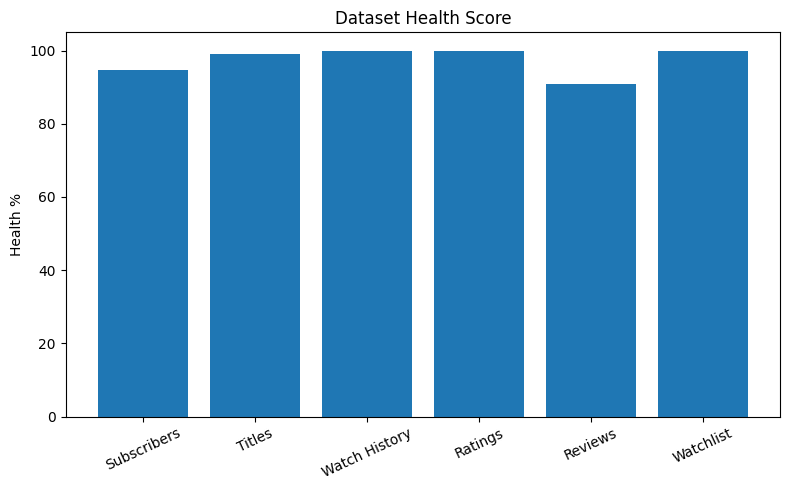

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

    health_df["Dataset"],

    health_df["Health Score (%)"]

)

plt.title(

    "Dataset Health Score"

)

plt.ylabel(

    "Health %"

)

plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig(

    "reports/Dataset_Health.png",

    dpi=300

)

plt.show()

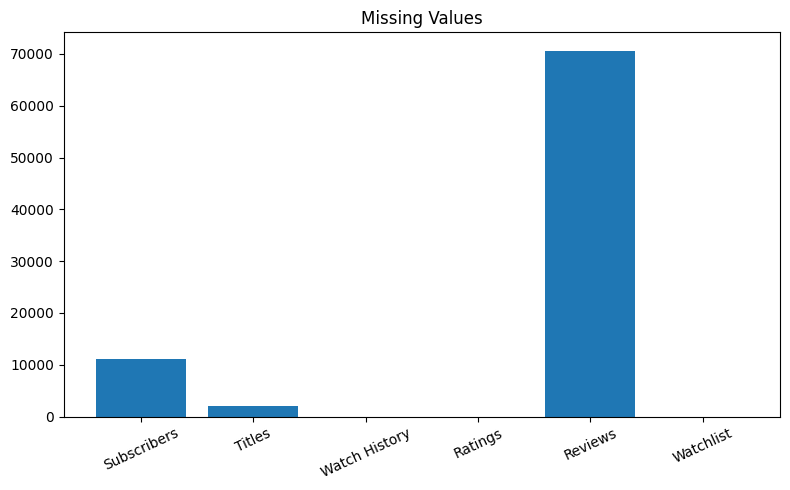

In [66]:
missing=[]

for name,dataframe in datasets.items():

    missing.append(

        [

            name,

            dataframe.isnull().sum().sum()

        ]

    )

missing_df=pd.DataFrame(

    missing,

    columns=[

        "Dataset",

        "Missing"

    ]

)

plt.figure(figsize=(8,5))

plt.bar(

    missing_df["Dataset"],

    missing_df["Missing"]

)

plt.title(

    "Missing Values"

)

plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig(

    "reports/MissingValues.png",

    dpi=300

)

plt.show()

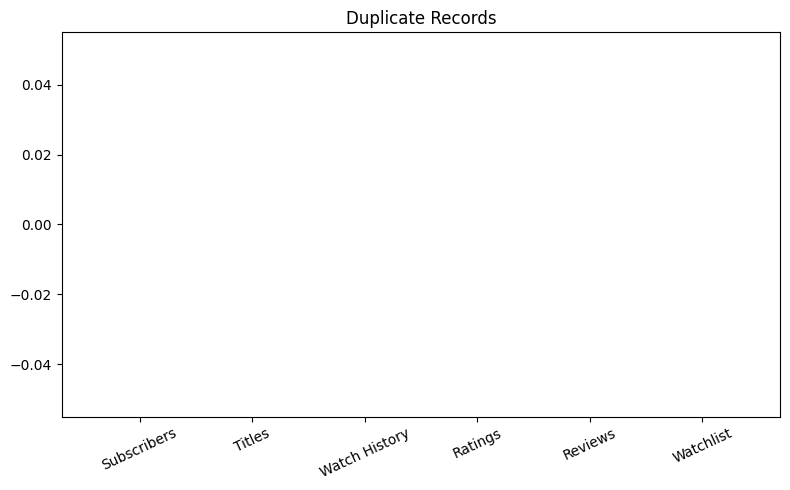

In [67]:
duplicates=[]

for name,dataframe in datasets.items():

    duplicates.append(

        [

            name,

            dataframe.duplicated().sum()

        ]

    )

duplicate_df=pd.DataFrame(

    duplicates,

    columns=[

        "Dataset",

        "Duplicates"

    ]

)

plt.figure(figsize=(8,5))

plt.bar(

    duplicate_df["Dataset"],

    duplicate_df["Duplicates"]

)

plt.title(

    "Duplicate Records"

)

plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig(

    "reports/DuplicateRecords.png",

    dpi=300

)

plt.show()

In [ ]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Table,
    TableStyle,
    Paragraph,
    Spacer
)

from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER

styles = getSampleStyleSheet()

title_style = styles["Heading1"]
title_style.alignment = TA_CENTER

heading_style = styles["Heading2"]
normal_style = styles["BodyText"]

report_path = "reports/Data_Quality_Report.pdf"

doc = SimpleDocTemplate(report_path)

elements = []

# ---------------------------------------------------------
# TITLE
# ---------------------------------------------------------

elements.append(
    Paragraph(
        "StreamFlix Data Quality Report",
        title_style
    )
)

elements.append(Spacer(1, 20))

elements.append(
    Paragraph(
        "Phase 1 - Data Loading, Cleaning & Validation",
        heading_style
    )
)

elements.append(Spacer(1, 20))

# ---------------------------------------------------------
# EXECUTIVE SUMMARY
# ---------------------------------------------------------

summary_text = """
This report summarizes the data quality assessment performed
on all StreamFlix datasets.

The following checks were completed:

• Missing Value Analysis

• Duplicate Detection

• Primary Key Validation

• Data Type Validation

• Referential Integrity

• Business Rule Validation

• Outlier Detection
"""

elements.append(
    Paragraph(summary_text, normal_style)
)

elements.append(Spacer(1,20))

# ---------------------------------------------------------
# DATASET SUMMARY
# ---------------------------------------------------------

elements.append(
    Paragraph(
        "Dataset Summary",
        heading_style
    )
)

table_data = [[
    "Dataset",
    "Rows",
    "Columns",
    "Missing",
    "Duplicates",
    "Memory (MB)",
    "Health %"
]]

for _, row in summary_df.iterrows():

    score = health_df.loc[
        health_df["Dataset"] == row["Dataset"],
        "Health Score (%)"
    ].values[0]

    table_data.append([
        str(row["Dataset"]),
        str(row["Rows"]),
        str(row["Columns"]),
        str(row["Missing"]),
        str(row["Duplicates"]),
        str(row["Memory(MB)"]),
        f"{score}%"
    ])

table = Table(table_data)

table.setStyle(TableStyle([

    ("BACKGROUND",(0,0),(-1,0),colors.darkblue),

    ("TEXTCOLOR",(0,0),(-1,0),colors.white),

    ("GRID",(0,0),(-1,-1),1,colors.black),

    ("FONTNAME",(0,0),(-1,0),"Helvetica-Bold"),

    ("ALIGN",(0,0),(-1,-1),"CENTER"),

    ("BACKGROUND",(0,1),(-1,-1),colors.beige),

    ("BOTTOMPADDING",(0,0),(-1,0),10)

]))

elements.append(table)

elements.append(Spacer(1,25))

# ---------------------------------------------------------
# VALIDATION RESULTS
# ---------------------------------------------------------

elements.append(
    Paragraph(
        "Validation Results",
        heading_style
    )
)

validation_table = [["Validation Check", "Failed Records"]]

for _, row in validation_df.iterrows():

    validation_table.append([
        str(row["Validation"]),
        str(row["Failed Records"])
    ])

table2 = Table(validation_table)

table2.setStyle(TableStyle([

    ("BACKGROUND",(0,0),(-1,0),colors.darkgreen),

    ("TEXTCOLOR",(0,0),(-1,0),colors.white),

    ("GRID",(0,0),(-1,-1),1,colors.black),

    ("FONTNAME",(0,0),(-1,0),"Helvetica-Bold"),

    ("ALIGN",(0,0),(-1,-1),"CENTER"),

    ("BACKGROUND",(0,1),(-1,-1),colors.whitesmoke)

]))

elements.append(table2)

elements.append(Spacer(1,25))

# ---------------------------------------------------------
# CONCLUSION
# ---------------------------------------------------------

elements.append(
    Paragraph(
        "Conclusion",
        heading_style
    )
)

conclusion = f"""
The Phase 1 Data Cleaning process completed successfully.

Total datasets analysed: <b>{len(datasets)}</b><br/>

Validation checks performed: <b>{len(validation_df)}</b><br/>

The cleaned datasets are now ready for Exploratory Data Analysis (EDA),
KPI calculation, SQL analysis, and Power BI dashboard development.
"""

elements.append(
    Paragraph(
        conclusion,
        normal_style
    )
)

# ---------------------------------------------------------
# BUILD PDF
# ---------------------------------------------------------

doc.build(elements)

logger.info("Data Quality PDF Report Generated Successfully.")

2026-07-21 16:45:05,560 | INFO | Data Quality PDF Report Generated Successfully.


In [69]:
execution_time=round(

    time.time()-start_time,

    2

)

logger.info(

    f"Execution Time : {execution_time} Seconds"

)

print(

    f"Execution Time : {execution_time} Seconds"

)

2026-07-21 16:45:05,573 | INFO | Execution Time : 37.34 Seconds


Execution Time : 37.34 Seconds


In [70]:
print("\n")

print("="*90)

print("STREAMFLIX DATA CLEANING COMPLETED")

print("="*90)

print()

print("Datasets Loaded :",len(datasets))

print("Validation Checks :",len(validation_report))

print("Reports Generated : 5")

print("Cleaned CSV Files : 6")

print("Health Score Report : Yes")

print("Validation Report : Yes")

print("Execution Successful")

print()

print("="*90)



STREAMFLIX DATA CLEANING COMPLETED

Datasets Loaded : 6
Validation Checks : 18
Reports Generated : 5
Cleaned CSV Files : 6
Health Score Report : Yes
Validation Report : Yes
Execution Successful



In [71]:
logger.info("="*90)

logger.info("STREAMFLIX PHASE 1 COMPLETED SUCCESSFULLY")

logger.info("="*90)

logger.info(f"Execution Time : {execution_time} Seconds")

logger.info("Reports exported to reports/")

logger.info("Cleaned datasets exported to data/cleaned/")

2026-07-21 16:45:05,617 | INFO | ==========================================================================================
2026-07-21 16:45:05,620 | INFO | STREAMFLIX PHASE 1 COMPLETED SUCCESSFULLY
2026-07-21 16:45:05,621 | INFO | ==========================================================================================
2026-07-21 16:45:05,623 | INFO | Execution Time : 37.34 Seconds
2026-07-21 16:45:05,624 | INFO | Reports exported to reports/
2026-07-21 16:45:05,624 | INFO | Cleaned datasets exported to data/cleaned/
